In [4]:
import numpy as np

In [5]:
Re = 6371  # km2
A = 4 * np.pi * Re**2
for z in range(13):
    npix = 12 * 4**z
    Apix = A / npix
    print(f'{z}: Pixel A, srqt(A): {Apix:.2f} km2, {np.sqrt(Apix):.2f}')

0: Pixel A, srqt(A): 42505372.66 km2, 6519.61
1: Pixel A, srqt(A): 10626343.16 km2, 3259.81
2: Pixel A, srqt(A): 2656585.79 km2, 1629.90
3: Pixel A, srqt(A): 664146.45 km2, 814.95
4: Pixel A, srqt(A): 166036.61 km2, 407.48
5: Pixel A, srqt(A): 41509.15 km2, 203.74
6: Pixel A, srqt(A): 10377.29 km2, 101.87
7: Pixel A, srqt(A): 2594.32 km2, 50.93
8: Pixel A, srqt(A): 648.58 km2, 25.47
9: Pixel A, srqt(A): 162.15 km2, 12.73
10: Pixel A, srqt(A): 40.54 km2, 6.37
11: Pixel A, srqt(A): 10.13 km2, 3.18
12: Pixel A, srqt(A): 2.53 km2, 1.59


In [6]:
import healpix as hp

In [7]:
hp.pix2ang?

Signature: hp.pix2ang(nside, ipix, nest=False, lonlat=False)
Docstring: <no docstring>
File:      ~/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/healpix/__init__.py
Type:      function

In [8]:
z = 3
nside = 2**z
lon, lat = hp.pix2ang(nside, np.arange(12 * 4**z), nest=True, lonlat=True)

In [17]:
ds = None
x1 = 90
x2 = 150
y1 = -30
y2 = 40

In [13]:
import intake
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']

In [19]:
ds = cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT1H').to_dask()

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<Figure size 640x480 with 0 Axes>

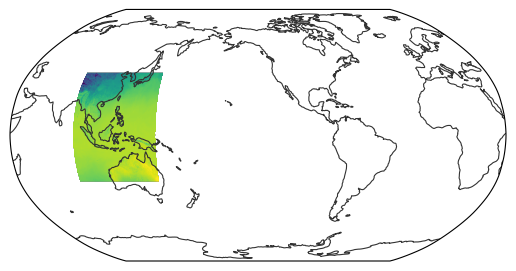

In [20]:
import easygems.healpix as egh
ds = ds.pipe(egh.attach_coords)
ds_region = ds.isel(cell=(ds.lon > x1) & (ds.lon < x2) & (ds.lat > y1) & (ds.lat < y2))
egh.healpix_show(ds_region.tas.isel(time=1))